"""Classical Hodgkin-Huxley model under constant current injection.

Python port of hh_sim.m. Same parameters, same shifted potential
convention of the 1952 papers, so rest is near V = 0 and the spike peak
near V = 100.

Call it and capture what you need:

    t, V, spk, rate = hh_sim()

Running the file directly (python hh_sim.py) prints the spike count and
rate at the default Id = 7. There is no MATLAB-style ans here, but t is
30001 elements of 0 to 300 in steps of 0.01, so avoid echoing the whole
return value in a notebook cell.

Regression checks with default parameters:
    Id = 7 gives sustained firing at 58.3 Hz
    Id = 5 gives no sustained firing
The 58.3 is solver independent: BDF, LSODA, Radau and RK45 all agree to
three digits, so a port that lands more than a Hz away has a real bug,
most likely a sign in an exponent. The removable singularities in
alpha_m and alpha_n at V = 25 and V = 10 are patched below; if you
rewrite them, check that alpha_m(25) and alpha_n(10) come out finite.

The reported rheobase depends on how you define repetitive firing: both
skipfrac and the spike count you demand of it will move the answer,
because the underlying bifurcation is subcritical. State the criterion
you used rather than treating the number as absolute.
"""

In [71]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
__all__ = ["hh_sim"]


# ---- gating rate functions (ms^-1), with removable singularities patched ----
def _am(V):
    return 1.0 if abs(V - 25) < 1e-6 else 0.1 * (25 - V) / (np.exp((25 - V) / 10) - 1)


def _bm(V):
    return 4 * np.exp(-V / 18)


def _ah(V):
    return 0.07 * np.exp(-V / 20)


def _bh(V):
    return 1 / (np.exp((30 - V) / 10) + 1)


def _an(V):
    return 0.1 if abs(V - 10) < 1e-6 else 0.01 * (10 - V) / (np.exp((10 - V) / 10) - 1)


def _bn(V):
    return 0.125 * np.exp(-V / 80)


def hh_sim(Id=6.0, tmax=300.0, gK=36.0, gNa=120.0, skipfrac=0.4):
    """Integrate the HH model under constant current.

    Parameters
    ----------
    Id : injected current density (uA/cm^2). Defaults to 7, above
         rheobase, so hh_sim() with no arguments gives repetitive
         firing.
    tmax : simulation duration (ms).
    gK, gNa : maximal conductances (mS/cm^2).
    skipfrac : fraction of the trace discarded before counting spikes, so
        that the onset transient is not mistaken for repetitive firing.

    Returns
    -------
    t, V : time vector (ms) and voltage trace (mV).
    spk : spike times, upward crossings of 40 mV.
    rate : mean firing rate in Hz over the counted window, 0 if fewer
        than two spikes.
    """
    C, gL, ENa, EK, EL = 1.0, 0.3, 115.0, -12.0, 10.6

    def rhs(_, y):
        V, m, h, n = y
        INa = gNa * m**3 * h * (V - ENa)
        IK = gK * n**4 * (V - EK)
        IL = gL * (V - EL)
        return [
            (Id - INa - IK - IL) / C,
            _am(V) * (1 - m) - _bm(V) * m,
            _ah(V) * (1 - h) - _bh(V) * h,
            _an(V) * (1 - n) - _bn(V) * n,
        ]

    V0 = 0.0  # steady state gating at rest
    y0 = [
        V0,
        _am(V0) / (_am(V0) + _bm(V0)),
        _ah(V0) / (_ah(V0) + _bh(V0)),
        _an(V0) / (_an(V0) + _bn(V0)),
    ]

    t = np.arange(0, tmax + 1e-9, 0.01)
    sol = solve_ivp(rhs, [0, tmax], y0, method="BDF", t_eval=t,
                    rtol=1e-8, atol=1e-10, max_step=0.05)
    V = sol.y[0]

    i0 = max(1, int(round(skipfrac * len(t))))
    up = np.flatnonzero((V[i0:-1] < 40) & (V[i0 + 1:] >= 40)) + i0
    spk = t[up]

    rate = 1000 * (len(spk) - 1) / (spk[-1] - spk[0]) if len(spk) >= 2 else 0.0
    return t, V, spk, rate


if __name__ == "__main__":
    t, V, spk, rate = hh_sim()
    print(f"Id = 6: {len(spk)} spikes, rate = {rate:.1f} Hz")


Id = 6: 0 spikes, rate = 0.0 Hz


## Part a - Finding the rheobase

In [91]:
def hh_simple(current):
    t, V, spk, rate = hh_sim(Id=current, tmax=300.0, gK=36.0, gNa=120.0, skipfrac=0.8)
    return rate

In [21]:
hh_simple(7)

58.30903790087463

In [116]:
def bisection(a,b, tol, func):
    '''this is not exactly a bisection function,
    as we are attempting to find the smallest possible
    current that produces repetitive spikes'''
    lower = a
    upper = b

    while upper - lower > tol:
        mid = (lower+upper)/2
        f_lower = func(lower)
        f_upper = func(upper)
        f_mid = func(mid)
        
        if f_mid + f_lower == 0:
            lower = mid
            print("New interval:", lower, "to", upper)
        else:
            upper = mid
            print("New interval:", lower, "to", upper)

    # once we are here, the difference between lower and upper is less than the tolerance
    # we will return the midpoint

    return upper

In [118]:
rheobase = bisection(6,7,.0001, hh_simple)

New interval: 6 to 6.5
New interval: 6.25 to 6.5
New interval: 6.25 to 6.375
New interval: 6.25 to 6.3125
New interval: 6.25 to 6.28125
New interval: 6.25 to 6.265625
New interval: 6.2578125 to 6.265625
New interval: 6.2578125 to 6.26171875
New interval: 6.259765625 to 6.26171875
New interval: 6.2607421875 to 6.26171875
New interval: 6.26123046875 to 6.26171875
New interval: 6.26123046875 to 6.261474609375
New interval: 6.2613525390625 to 6.261474609375
New interval: 6.2613525390625 to 6.26141357421875


In [122]:
rheobase

6.26141357421875

45.004500450045064


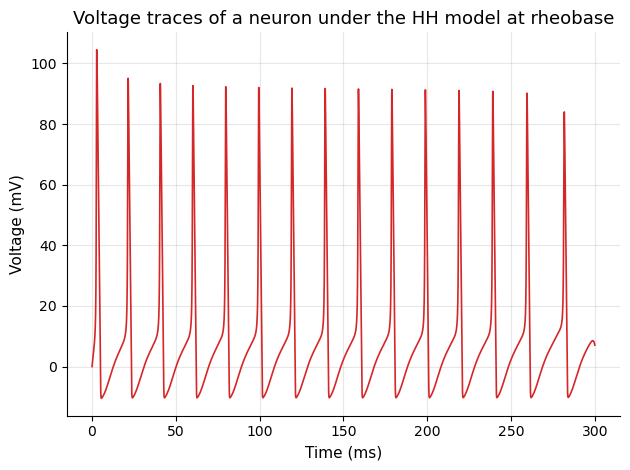

In [167]:
# test the current for rheobase

t_test, V_test, _, rate =  hh_sim(Id=rheobase, tmax=300.0, gK=36.0, gNa=120.0, skipfrac=0.8)
print(rate)
plt.plot(t_test, V_test,
         color="#d62728", linewidth=1.2)
plt.title("Voltage traces of a neuron under the HH model at rheobase", fontsize=13)
plt.xlabel("Time (ms)", fontsize=11)
plt.ylabel("Voltage (mV)", fontsize=11)
plt.grid(alpha=0.3)

sns.despine()  
plt.tight_layout()
plt.show()

In [142]:
t, V_low, _ , _ = hh_sim(Id=rheobase - .01, tmax=300.0, gK=36.0, gNa=120.0, skipfrac=0.4)

In [144]:
_, V_high, _ , _ = hh_sim(Id=rheobase + .01, tmax=300.0, gK=36.0, gNa=120.0, skipfrac=0.4)

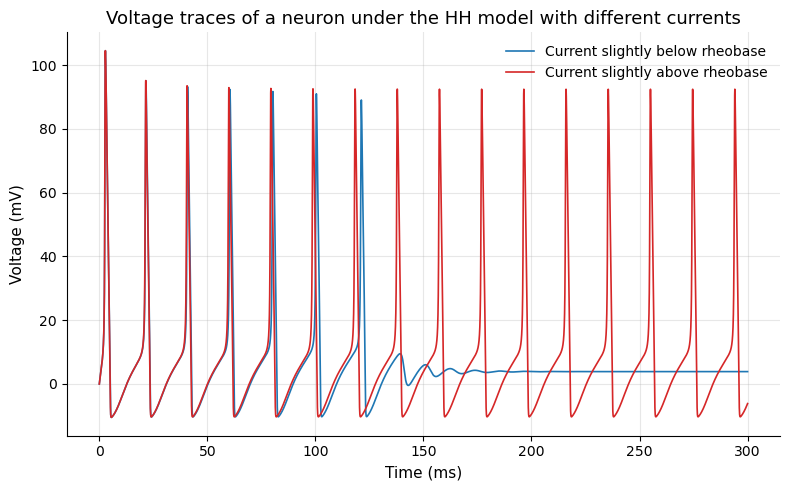

In [169]:
plt.figure(figsize=(8, 5))

plt.plot(t, V_low, label="Current slightly below rheobase", 
         color="#1f77b4", linewidth=1.2)
plt.plot(t, V_high, label="Current slightly above rheobase", 
         color="#d62728", linewidth=1.2)

plt.title("Voltage traces of a neuron under the HH model with different currents", fontsize=13)
plt.xlabel("Time (ms)", fontsize=11)
plt.ylabel("Voltage (mV)", fontsize=11)
plt.legend(frameon=False, fontsize=10)
plt.grid(alpha=0.3)

sns.despine()  
plt.tight_layout()
plt.savefig("neuron_firing_fig1", dpi=300, bbox_inches="tight")
plt.show()

## Part B - Bifurcation structure

In [188]:
id_vals = np.linspace(rheobase, 2*rheobase, 50)
rate_vals = np.empty(len(id_vals))

In [211]:
for idx in range(len(id_vals)):
    t, V, spk, rate = hh_sim(Id=id_vals[idx], tmax=300.0, gK=36.0, gNa=120.0, skipfrac=.4)
    rate_vals[idx] = rate

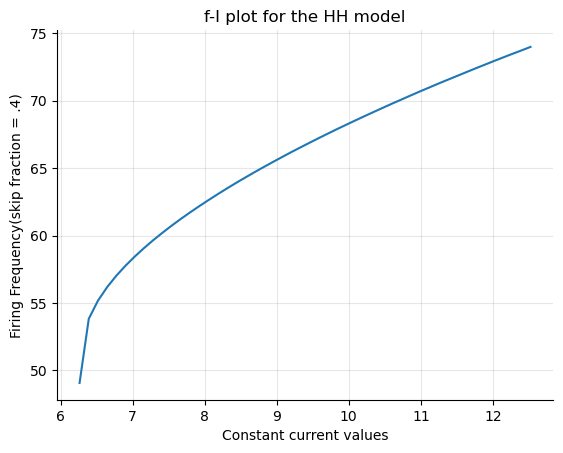

In [233]:
plt.plot(id_vals, rate_vals, color="#1f77b4")
plt.title("f-I plot for the HH model")
plt.xlabel("Constant current values")
plt.ylabel("Firing Frequency(skip fraction = .4)")
plt.grid(alpha = .3)

sns.despine()

plt.savefig("f-I_plot1.png")
plt.show()

In [231]:
onset_rate = min(rate_vals)
onset_rate

49.07459338194055

## Part C - Another rheobase calculation

In [203]:
def hh_simple2(current):
    t, V, spk, rate = hh_sim(Id=current, tmax=300.0, gK=30.0, gNa=120.0, skipfrac=0.8)
    return rate

In [205]:
rheobase2 = bisection(5,7, .0001, hh_simple2)

New interval: 5 to 6.0
New interval: 5 to 5.5
New interval: 5 to 5.25
New interval: 5 to 5.125
New interval: 5 to 5.0625
New interval: 5 to 5.03125
New interval: 5 to 5.015625
New interval: 5 to 5.0078125
New interval: 5 to 5.00390625
New interval: 5 to 5.001953125
New interval: 5 to 5.0009765625
New interval: 5 to 5.00048828125
New interval: 5 to 5.000244140625
New interval: 5 to 5.0001220703125
New interval: 5 to 5.00006103515625


In [207]:
rheobase2

5.00006103515625

In [212]:
id_vals2 = np.linspace(rheobase2, 2*rheobase2, 50)
rate_vals2 = np.empty(len(id_vals2))

for idx in range(len(id_vals2)):
    t, V, spk, rate = hh_sim(Id=id_vals2[idx], tmax=300.0, gK=30.0, gNa=120.0, skipfrac=.4)
    rate_vals2[idx] = rate

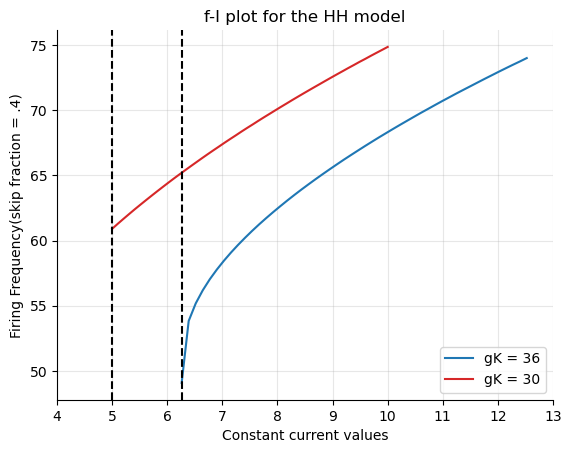

In [238]:
plt.plot(id_vals, rate_vals, 
         color="#1f77b4", label = "gK = 36")
plt.plot(id_vals2, rate_vals2, 
         color="#d62728", label = "gK = 30")

plt.axvline(x = rheobase, linestyle = "--", color = "black")
plt.axvline(x = rheobase2, linestyle = "--", color = "black")
plt.title("f-I plot for the HH model")
plt.xlabel("Constant current values")
plt.ylabel("Firing Frequency(skip fraction = .4)")
plt.grid(alpha = .3)
plt.legend()

plt.xlim(4,13)
sns.despine()
plt.savefig("f-I_plot2.png")
plt.show()